<a href="https://colab.research.google.com/github/Oneness-Company/Oneness-Company2/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,accuracy_score


In [65]:
dataset = pd.read_csv('/content/Housing.csv')
dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [66]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
dataset[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']]=dataset[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']].apply(lb.fit_transform)

In [67]:
correlation = dataset.corr(numeric_only=True)

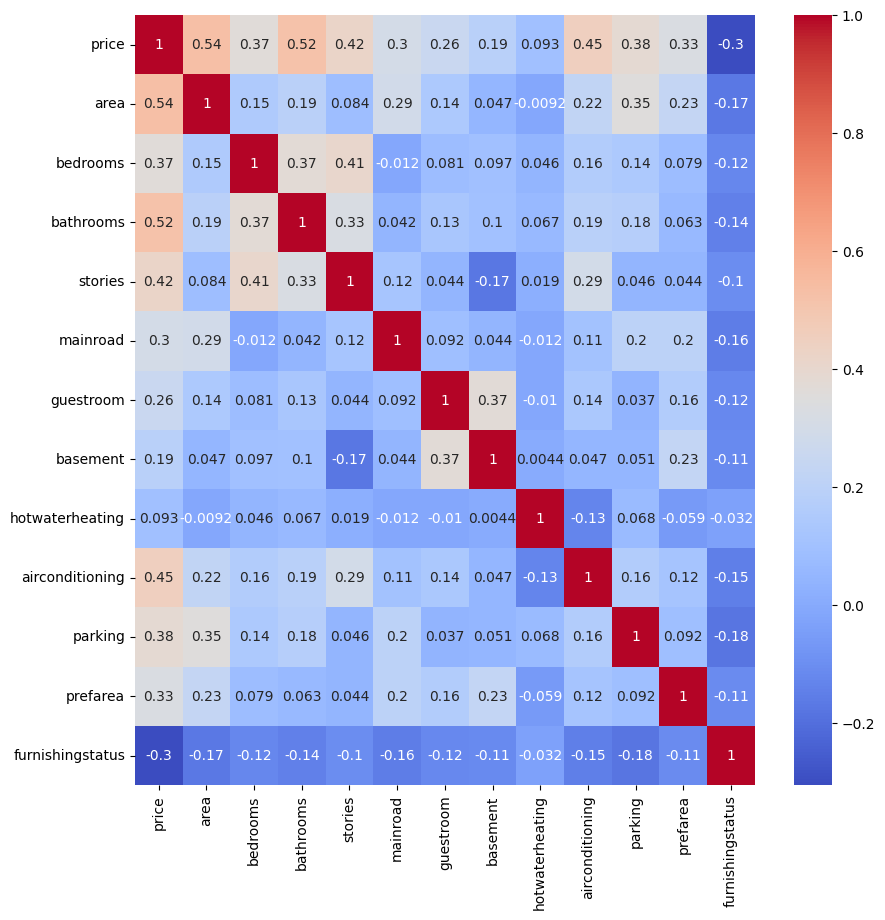

In [68]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.show()

In [69]:
dataset.drop('furnishingstatus',axis=1,inplace=True)


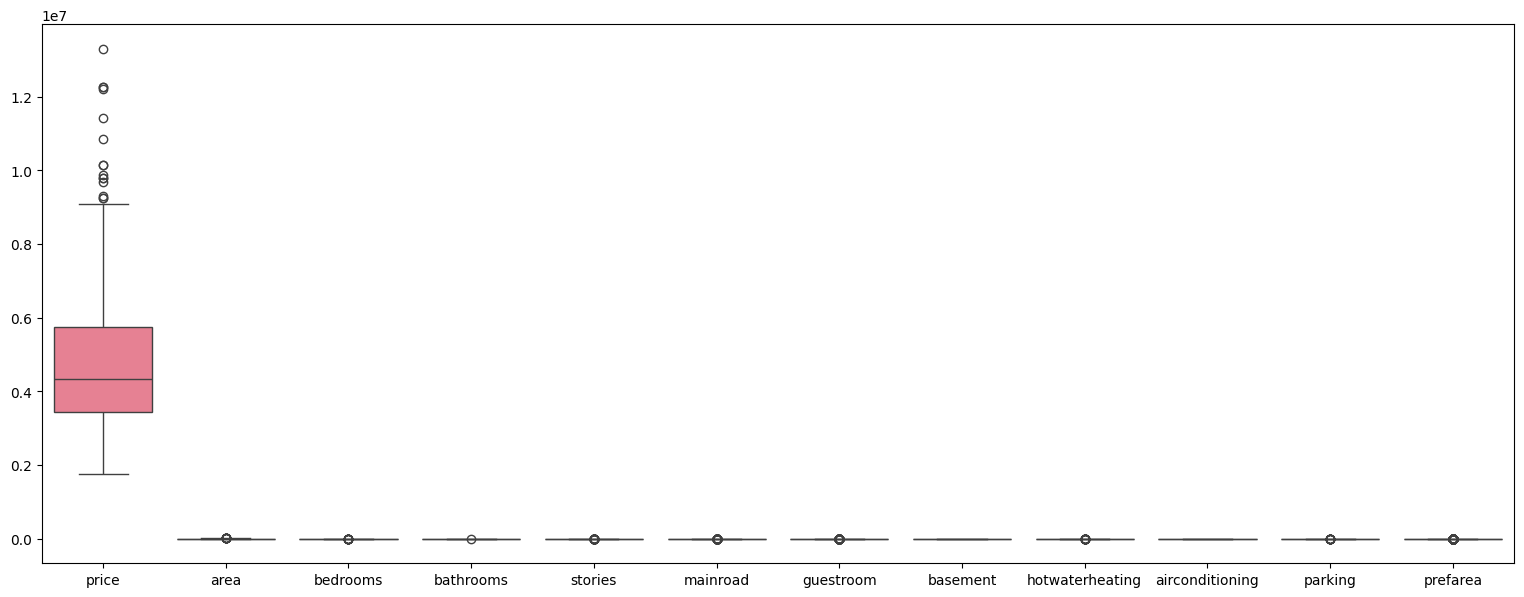

In [70]:
plt.figure(figsize=(19,7))
import seaborn as sns
sns.boxplot(data = dataset)
plt.show()


In [71]:
Q1 = dataset['price'].quantile(0.25)
Q3 = dataset['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
dataset = dataset[(dataset['price'] >= lower_bound) & (dataset['price']<= upper_bound)]


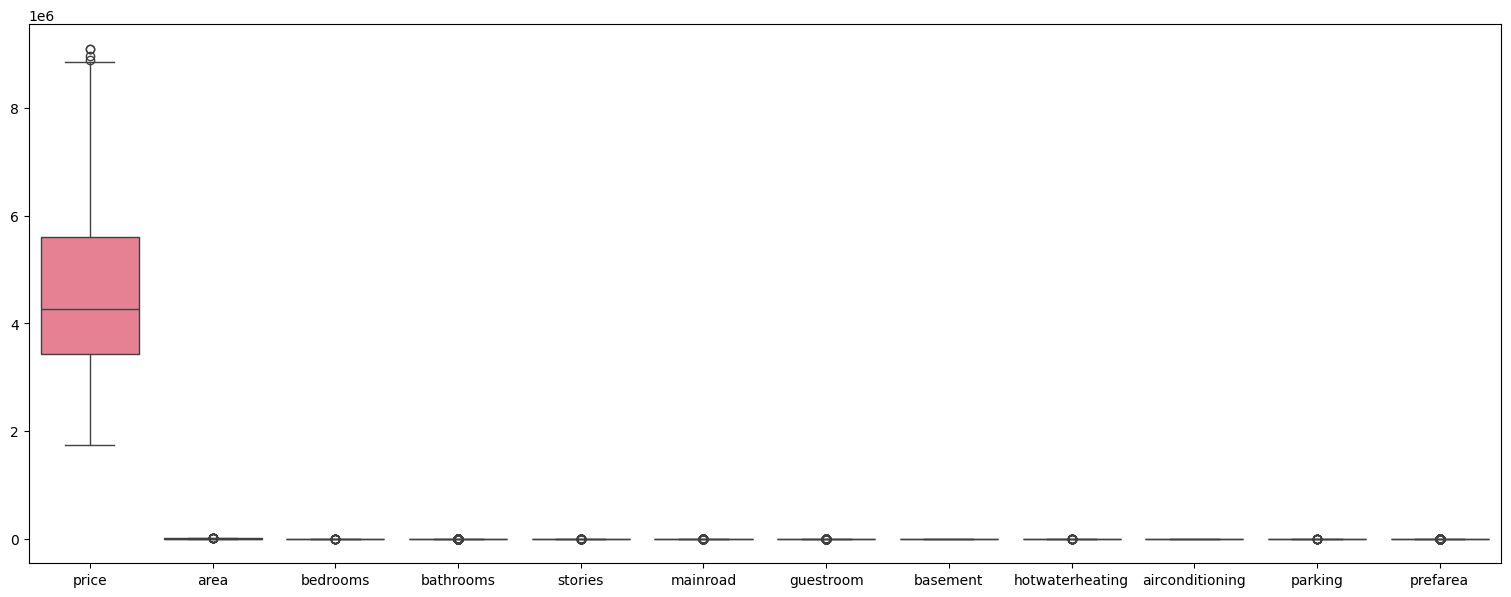

In [72]:
plt.figure(figsize=(19,7))
import seaborn as sns
sns.boxplot(data = dataset)
plt.show()


In [73]:
X = dataset.drop('price',axis=1)
y = dataset['price']

In [74]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
dataset= sc.fit_transform(dataset)

In [75]:
xtr,xte,ytr,yte = train_test_split(X,y,test_size=0.25,random_state=0)

In [76]:
xtr = sc.fit_transform(xtr)
xte = sc.transform(xte)

In [77]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(xtr,ytr)
ypred = rf.predict(xte)
rmse = mean_squared_error(yte,ypred,squared=False)
print(rmse)

1026226.4367111172


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [53]:
from sklearn.tree import DecisionTreeRegressor
dcf = DecisionTreeRegressor()
dcf.fit(xtr,ytr)
ypred = dcf.predict(xte)
rmse = mean_squared_error(yte,ypred,squared=False)
print(rmse)

1310659.4583770924


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [29]:
model = LinearRegression()
model.fit(xtr,ytr)
ypred = model.predict(xte)
rmse = mean_squared_error(yte,ypred,squared=False)
print(rmse)

994335.6362094845


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
